In [6]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.2 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics opencv-python-headless


In [1]:
!ls /kaggle/input/datasets/rishavsingh025/test-video3

12329614-hd_1080_1920_60fps.mp4


In [3]:
import cv2
import os
import pandas as pd

# ---- Config ----
VIDEO_PATH = "/kaggle/input/datasets/rishavsingh025/test-video3/12329614-hd_1080_1920_60fps.mp4"
OUTPUT_DIR = "/kaggle/working/extracted_frames"
FRAME_STEP = 15          # extract every Nth frame — tune this based on overlap (see note below)
BLUR_THRESHOLD = 60.0   # frames below this Laplacian variance are rejected as blurry

os.makedirs(OUTPUT_DIR, exist_ok=True)

def laplacian_variance(image):
    """Higher value = sharper image. Below threshold = likely blurry."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Video: {total_frames} frames @ {fps:.1f} fps")

frame_idx = 0
saved_count = 0
rejected_count = 0
log = []

while True:
    ret, frame = cap.read()
    if not ret:
        break

    if frame_idx % FRAME_STEP == 0:
        sharpness = laplacian_variance(frame)
        timestamp_sec = frame_idx / fps

        if sharpness >= BLUR_THRESHOLD:
            filename = f"frame_{frame_idx:06d}.jpg"
            filepath = os.path.join(OUTPUT_DIR, filename)
            cv2.imwrite(filepath, frame)
            saved_count += 1
            log.append({
                "frame_idx": frame_idx,
                "timestamp_sec": round(timestamp_sec, 3),
                "sharpness": round(sharpness, 1),
                "status": "kept",
                "filename": filename
            })
        else:
            rejected_count += 1
            log.append({
                "frame_idx": frame_idx,
                "timestamp_sec": round(timestamp_sec, 3),
                "sharpness": round(sharpness, 1),
                "status": "rejected_blurry",
                "filename": None
            })

    frame_idx += 1

cap.release()

log_df = pd.DataFrame(log)
log_df.to_csv(os.path.join(OUTPUT_DIR, "frame_log.csv"), index=False)

print(f"Done. Kept {saved_count} frames, rejected {rejected_count} as blurry.")
print(f"Frames saved to: {OUTPUT_DIR}")

Video: 718 frames @ 60.0 fps
Done. Kept 48 frames, rejected 0 as blurry.
Frames saved to: /kaggle/working/extracted_frames


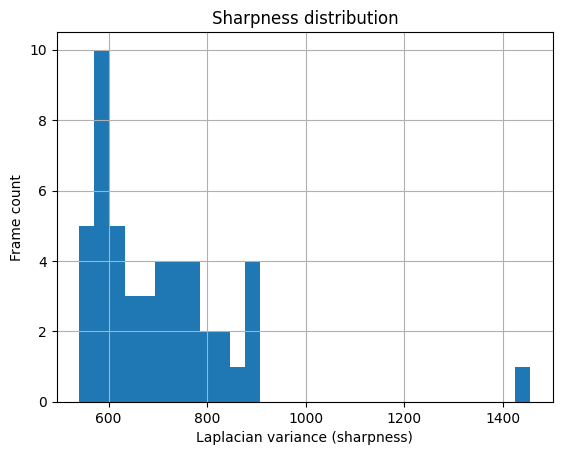

Kept 48 frames


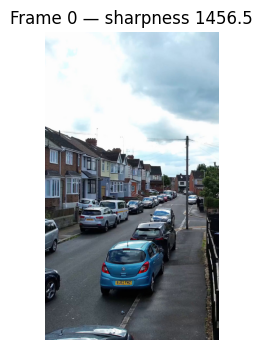

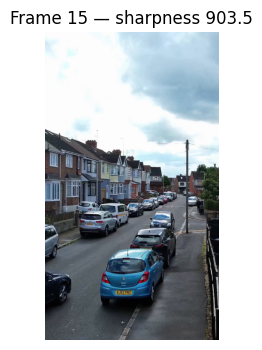

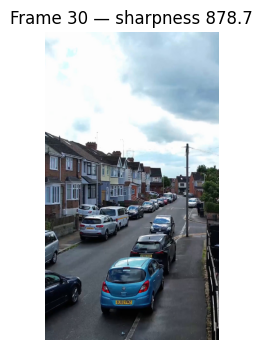

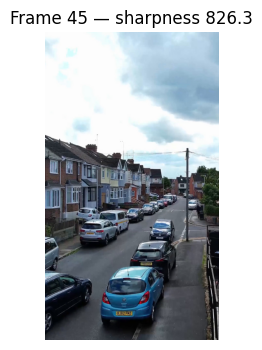

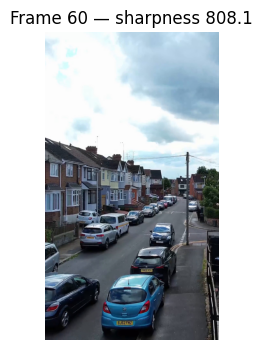

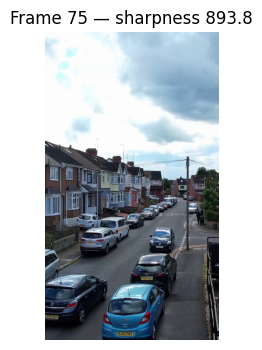

In [4]:
import matplotlib.pyplot as plt

log_df = pd.read_csv(f"{OUTPUT_DIR}/frame_log.csv")

log_df["sharpness"].hist(bins=30)
plt.xlabel("Laplacian variance (sharpness)")
plt.ylabel("Frame count")
plt.title("Sharpness distribution")
plt.show()

kept = log_df[log_df["status"] == "kept"]
print(f"Kept {len(kept)} frames")

for _, row in kept.head(6).iterrows():
    img = cv2.imread(os.path.join(OUTPUT_DIR, row["filename"]))
    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {row['frame_idx']} — sharpness {row['sharpness']:.1f}")
    plt.axis("off")
    plt.show()

In [7]:
from ultralytics import YOLO
import cv2
import numpy as np
import os
import json
import pandas as pd

# ---- Config ----
FRAMES_DIR = OUTPUT_DIR  # from Stage 0, e.g. /kaggle/working/extracted_frames
MASK_DIR = "/kaggle/working/masks"
VIS_DIR = "/kaggle/working/masked_preview"
os.makedirs(MASK_DIR, exist_ok=True)
os.makedirs(VIS_DIR, exist_ok=True)

# Classes we want to mask out (COCO class names YOLOv8 already knows)
DYNAMIC_CLASSES = {
    "person", "car", "truck", "bus", "motorcycle", "bicycle",
    "dog", "cat", "horse", "bird", "cow", "sheep"
}

model = YOLO("yolov8n-seg.pt")

kept = pd.read_csv(f"{FRAMES_DIR}/frame_log.csv")
kept = kept[kept["status"] == "kept"]

detection_log = []

for _, row in kept.iterrows():
    fname = row["filename"]
    img_path = os.path.join(FRAMES_DIR, fname)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # Start with an all-white mask (255 = valid/use this pixel)
    mask = np.full((h, w), 255, dtype=np.uint8)

    results = model.predict(img_path, verbose=False)[0]
    frame_detections = []

    if results.masks is not None:
        for seg_mask, box, cls_id, conf in zip(
            results.masks.data, results.boxes.xyxy,
            results.boxes.cls, results.boxes.conf
        ):
            class_name = model.names[int(cls_id)]
            if class_name not in DYNAMIC_CLASSES:
                continue  # skip classes we don't care about (e.g. random objects)

            # Resize YOLO's mask to full image size and blacken those pixels
            seg_mask_np = seg_mask.cpu().numpy()
            seg_mask_resized = cv2.resize(seg_mask_np, (w, h))
            mask[seg_mask_resized > 0.5] = 0  # 0 = ignore this pixel

            x1, y1, x2, y2 = box.cpu().numpy().tolist()
            frame_detections.append({
                "class": class_name,
                "confidence": round(float(conf), 3),
                "bbox": [round(x1,1), round(y1,1), round(x2,1), round(y2,1)]
            })

    # Save the binary mask (paired filename, same as COLMAP expects: image.jpg -> image.jpg.png)
    mask_path = os.path.join(MASK_DIR, f"{fname}.png")
    cv2.imwrite(mask_path, mask)

    # Save a visual preview: original frame with red overlay where masked
    vis = img.copy()
    vis[mask == 0] = [0, 0, 255]  # red where masked out
    overlay = cv2.addWeighted(img, 0.6, vis, 0.4, 0)
    cv2.imwrite(os.path.join(VIS_DIR, fname), overlay)

    detection_log.append({
        "frame_idx": int(row["frame_idx"]),
        "filename": fname,
        "detections": frame_detections,
        "num_objects": len(frame_detections)
    })

with open("/kaggle/working/detections_log.json", "w") as f:
    json.dump(detection_log, f, indent=2)

total_detections = sum(d["num_objects"] for d in detection_log)
frames_with_objects = sum(1 for d in detection_log if d["num_objects"] > 0)
print(f"Processed {len(detection_log)} frames")
print(f"Frames with at least one dynamic object: {frames_with_objects}")
print(f"Total detections: {total_detections}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Processed 48 frames
Frames with at least one dynamic object: 48
Total detections: 721


Total preview images: 48


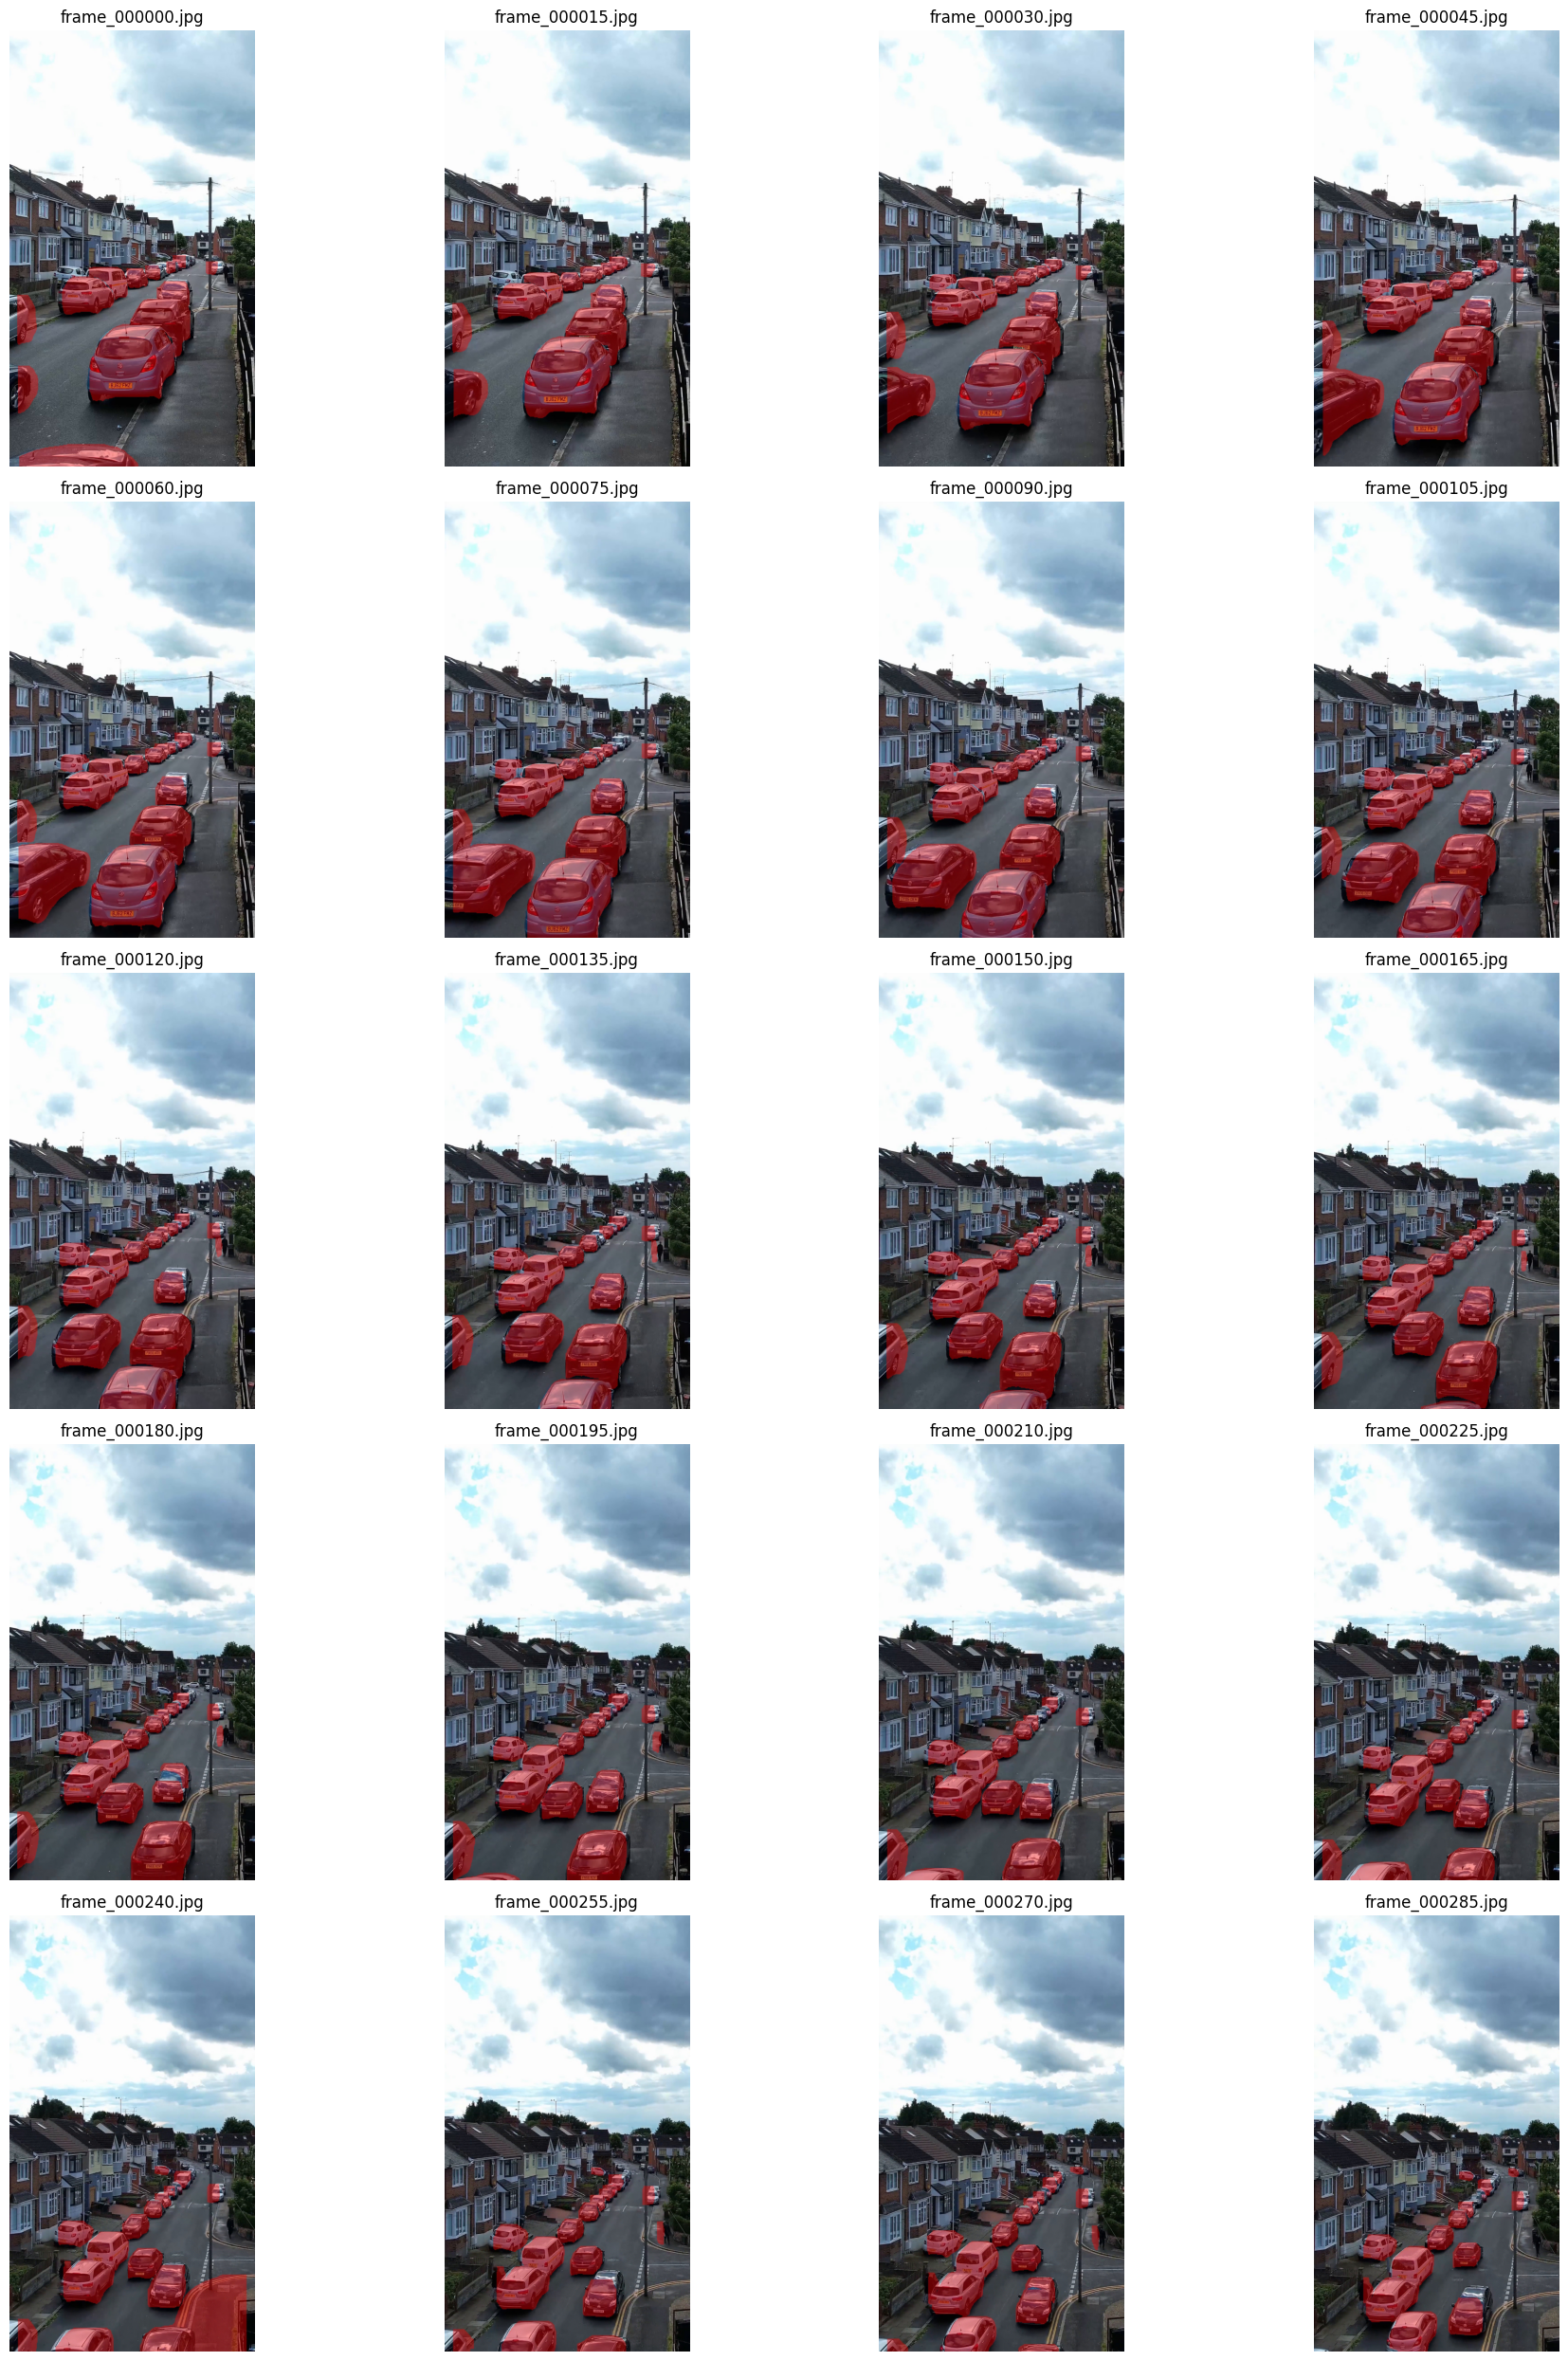

In [8]:
import os
import cv2
import math
import matplotlib.pyplot as plt

preview_dir = "/kaggle/working/masked_preview"

files = sorted([
    f for f in os.listdir(preview_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Total preview images:", len(files))

# Number of images to display
num_images = min(len(files), 20)

# Grid settings
cols = 4
rows = math.ceil(num_images / cols)

plt.figure(figsize=(20, rows * 5))

for i, fname in enumerate(files[:num_images]):
    img_path = os.path.join(preview_dir, fname)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(fname)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
import os
mask_files = sorted(os.listdir(MASK_DIR))
print(f"Total mask files: {len(mask_files)}")
print(mask_files[:5])


import cv2
sample_mask = cv2.imread(os.path.join(MASK_DIR, mask_files[0]), cv2.IMREAD_GRAYSCALE)
print(f"Mask shape: {sample_mask.shape}")
print(f"Unique values in mask: {sorted(set(sample_mask.flatten()))}")  # should just be [0, 255]

Total mask files: 48
['frame_000000.jpg.png', 'frame_000015.jpg.png', 'frame_000030.jpg.png', 'frame_000045.jpg.png', 'frame_000060.jpg.png']
Mask shape: (1920, 1080)
Unique values in mask: [np.uint8(0), np.uint8(255)]
